In [1]:
import bagpipes as pipes
import numpy as np
from numpy import random as rnd
import matplotlib.pyplot as plt

from scipy.integrate import simpson
from joblib import Parallel, delayed

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


In [2]:
import numpy as np
from scipy.integrate import simpson
import bagpipes as pipes
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

total_test_samples = 1000

# Carrega a lista de filtros
filt_splus_list = np.loadtxt("splus-filters/splus_filters.txt", dtype="str")
n_filters_splus = len(filt_splus_list)

cosmo = FlatLambdaCDM(H0=70.0, Om0=0.3)

central_wavs = np.zeros(n_filters_splus)
for j in range(n_filters_splus):
    filt = np.loadtxt(filt_splus_list[j])
    
    num = simpson(filt[:, 1] * filt[:, 0], x=filt[:, 0])
    den = simpson(filt[:, 1] / filt[:, 0], x=filt[:, 0])
    central_wavs[j] = np.sqrt(num / den)

def worker_bagpipes():
    rng = np.random.default_rng()

    # Redshift sampled uniformly between 0.0012 and 0.0046
    z = rng.uniform(0.0012, 0.0046)
    max_allowed_age = cosmo.age(z).value - 0.1

    # Define the 16 exact age bins (in Gyr) used in the paper
    age_bins_gyr = np.array([
        0.007, 0.021, 0.0425, 0.076, 0.1145, 0.1615, 0.23, 0.345, 
        0.545, 0.865, 1.37, 2.17, 3.44, 5.455, 8.645, 14.2
    ])
    
    # Ensure we only include bins that are physically possible at redshift z
    valid_ages_gyr = age_bins_gyr[age_bins_gyr <= max_allowed_age]
    n_bins = len(valid_ages_gyr)
    if n_bins == 0:
        valid_ages_gyr = np.array([max_allowed_age])
        n_bins = 1

    # Calculate boundaries for the constant (top-hat) SFH bins
    bin_edges_gyr = np.zeros(n_bins + 1)
    if n_bins > 1:
        bin_edges_gyr[1:-1] = (valid_ages_gyr[:-1] + valid_ages_gyr[1:]) / 2.0
    bin_edges_gyr[0] = 0.0
    bin_edges_gyr[-1] = max_allowed_age

    # Draw mass fractions for the bins from a Dirichlet distribution (alpha=1)
    mass_fractions = rng.dirichlet(np.ones(n_bins))
    
    # Metallicity enrichment bounds
    z_start = 0.008
    z_final = rng.uniform(0.010, 0.030)

    # Two-component attenuation of Charlot & Fall (2000)
    tau_ism = -1.0
    while tau_ism <= 0:
        tau_ism = rng.normal(loc=0.3, scale=0.08)
    
    tau_bc = 10**rng.uniform(np.log10(0.5), np.log10(4.0))
    total_tau = tau_ism + tau_bc
    mu_frac = tau_ism / total_tau

    dust = {
        "type": "CF00",
        "Av": 1.086 * total_tau,  
        "mu": mu_frac,     
        "n": 0.7         
    }

    nebular = {
        "logU": rng.uniform(-4.0, -1.0)
    }

    model_components = {
        "redshift": z,
        "veldisp": 150.0,
        "t_bc": 0.01,
        "dust": dust,
        "nebular": nebular
    }

    # We track cumulative mass to apply chemical enrichment over time. 
    # Because Z_start defines the oldest populations, we iterate backwards.
    cumulative_mass_frac = 0.0
    
    for i in reversed(range(n_bins)):
        bin_mass_frac = mass_fractions[i]
        bin_mass = bin_mass_frac * 15e6  # Normalize exactly to 15 million solar masses
        
        # Z(age) = Z_start + (Z_final - Z_start) * (M_age / M_tot)
        # We approximate M_age / M_tot to the midpoint of the current bin's addition
        m_age_frac = cumulative_mass_frac + (bin_mass_frac / 2.0)
        bin_met = z_start + (z_final - z_start) * m_age_frac
        
        # Add a constant (top-hat) SFH component for this specific age bin
        # Numerical safety: skip negligible mass bins to avoid log10(0) domain errors
        if bin_mass > 1.0: 
            model_components[f"constant{i+1}"] = {
                "age_min": bin_edges_gyr[i],
                "age_max": bin_edges_gyr[i+1],
                "massformed": np.log10(bin_mass),
                "metallicity": bin_met
            }
            
        cumulative_mass_frac += bin_mass_frac

    model = pipes.model_galaxy(model_components, filt_list=filt_splus_list)

    if np.any(model.photometry <= 0.0):
        return np.full(n_filters_splus, np.nan)
    
    test_splus = -2.5 * np.log10(model.photometry) - 5 * np.log10(central_wavs) - 2.406
    return test_splus

if __name__ == '__main__':
    threads = 10

    mock_test = np.array(
        Parallel(n_jobs=threads, verbose=10)(
            delayed(worker_bagpipes)() for _ in range(total_test_samples)
        )
    )

    np.savetxt("output.csv", mock_test, delimiter=",", header=",".join(filt_splus_list), comments="")

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sa

[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    3.1s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:    3.4s
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:    3.9s
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    4.3s
[Parallel(n_jobs=10)]: Done  41 tasks      | elapsed:    4.6s
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:    5.0s
[Parallel(n_jobs=10)]: Done  65 tasks      | elapsed:    5.4s
[Parallel(n_jobs=10)]: Done  78 tasks      | elapsed:    5.9s
[Parallel(n_jobs=10)]: Done  93 tasks      | elapsed:    6.4s
[Parallel(n_jobs=10)]: Done 108 tasks      | elapsed:    6.9s
[Parallel(n_jobs=10)]: Done 125 tasks      | elapsed:    7.5s
[Parallel(n_jobs=10)]: Done 142 tasks      | elapsed:    8.1s
[Parallel(n_jobs=10)]: Done 161 tasks      | elapsed:    8.8s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    9.5s
[Parallel(n_jobs=10)]: Done 201 tasks      | elapsed:   10.3s
[Parallel(n_jobs=10)]: Done 222 tasks      | elapsed:   11.1s
[Paralle

In [7]:
import pandas as pd

# Carregamento dos dados do modelo sintetico e do splus
splus_all_data = pd.read_csv("dr3_alldata.csv")
filter_splus = (splus_all_data['u_auto'] < 21.3) & (splus_all_data['g_auto'] < 21.3) & (splus_all_data['r_auto'] < 21.3) & (splus_all_data['i_auto'] < 21.3) & (splus_all_data['z_auto'] < 21.3) \
               & (splus_all_data['J0378_auto'] < 21.3) & (splus_all_data['J0395_auto'] < 21.3) & (splus_all_data['J0410_auto'] < 21.3) & (splus_all_data['J0430_auto'] < 21.3) \
               & (splus_all_data['J0515_auto'] < 21.3) & (splus_all_data['J0660_auto'] < 21.3) & (splus_all_data['J0861_auto'] < 21.3) & (splus_all_data['e_r_auto'] < 0.01)

splus_data = splus_all_data[filter_splus].reset_index(drop=True)

['uJAVA', 'F0378', 'F0395', 'F0410', 'F0430', 'gSDSS', 'F0515', 'rSDSS', 'F0660', 'iSDSS', 'F0861', 'zSDSS']


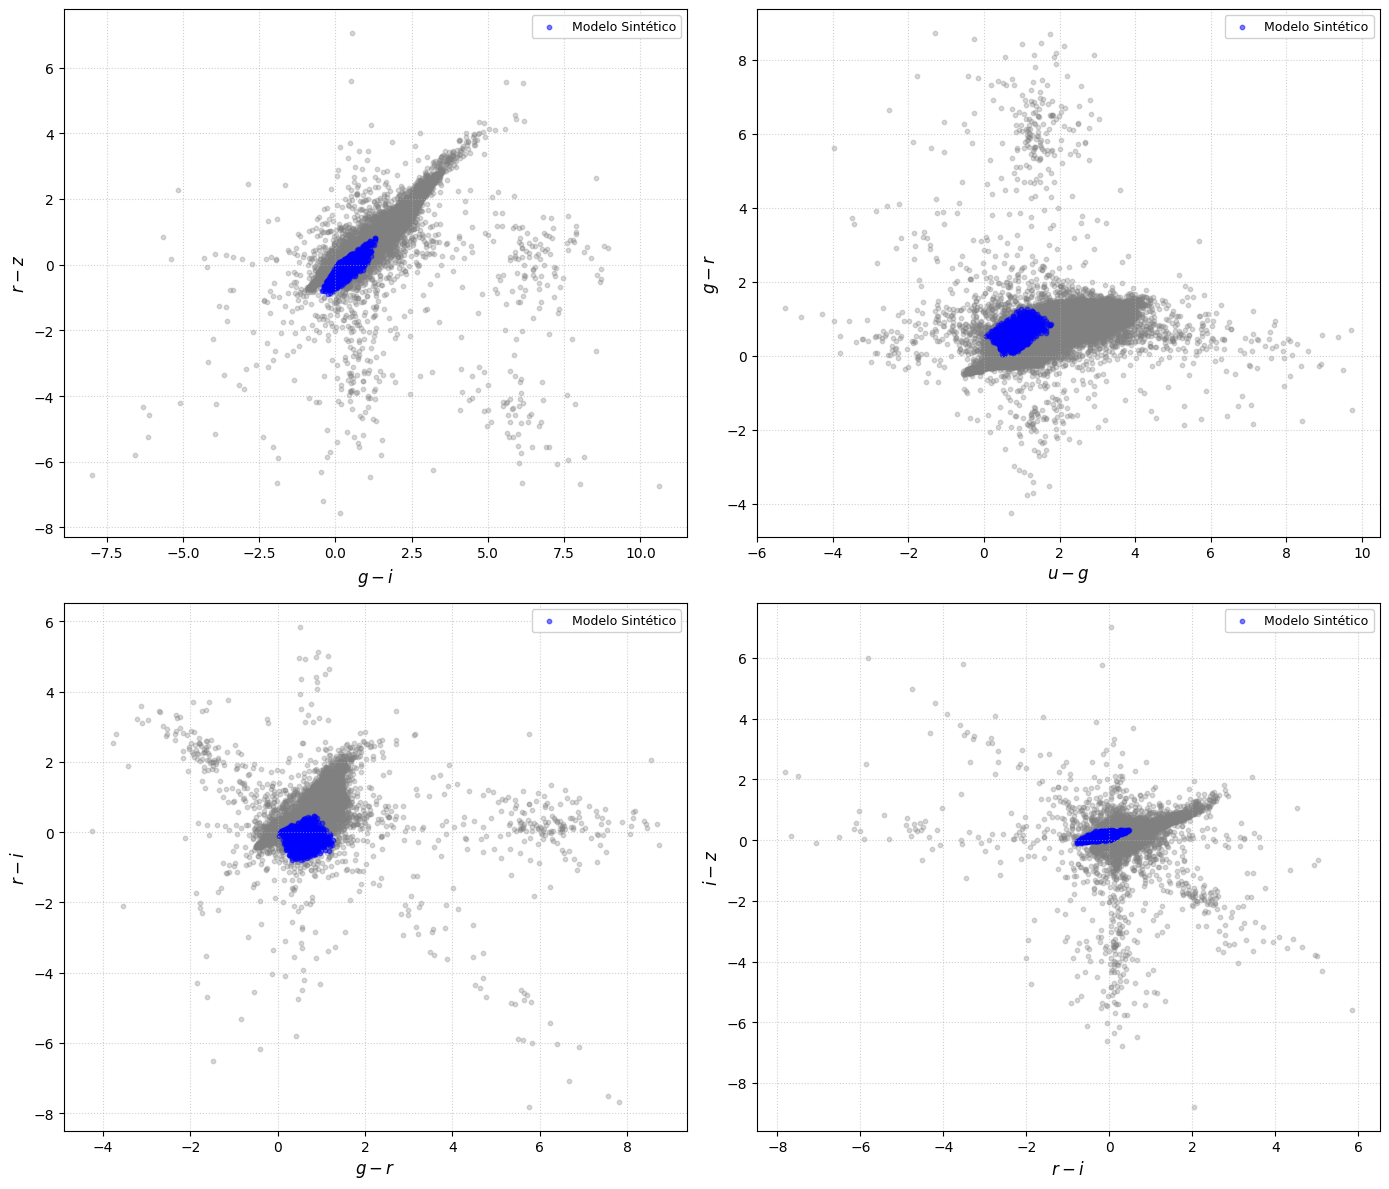

In [8]:
from scipy.spatial import ConvexHull
from matplotlib.lines import Line2D

plt.rcParams["text.usetex"] = False

model_grid = np.loadtxt("output.csv", delimiter=",", skiprows=1)
filt_splus_list = [filter.split("/")[1].split(".")[0] for filter in np.loadtxt("splus-filters/splus_filters.txt", dtype="str")]

print(filt_splus_list)

plot_configs = [
    {'x': ('gSDSS', 'iSDSS'), 'y': ('rSDSS', 'zSDSS'), 'xlab': '$g - i$', 'ylab': '$r - z$'},
    {'x': ('uJAVA', 'gSDSS'),  'y': ('gSDSS', 'rSDSS'), 'xlab': '$u - g$', 'ylab': '$g - r$'},
    {'x': ('gSDSS', 'rSDSS'), 'y': ('rSDSS', 'iSDSS'), 'xlab': '$g - r$', 'ylab': '$r - i$'},
    {'x': ('rSDSS', 'iSDSS'), 'y': ('iSDSS', 'zSDSS'), 'xlab': '$r - i$', 'ylab': '$i - z$'}
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

cmap = plt.get_cmap('jet')

# Loop sobre cada subplot e sua configuração de cor
for ax_idx, (ax, config) in enumerate(zip(axes, plot_configs)):
    
    b1_x, b2_x = config['x']
    b1_y, b2_y = config['y']
    
    all_x, all_y = [], []

    ax.scatter(model_grid[:, filt_splus_list.index(b1_x)] - model_grid[:, filt_splus_list.index(b2_x)],
               model_grid[:, filt_splus_list.index(b1_y)] - model_grid[:, filt_splus_list.index(b2_y)],
               c='blue', s=10, alpha=0.5, label='Modelo Sintético', zorder=1)

    splus_data_x = splus_data[b1_x[0] + '_auto'] - splus_data[b2_x[0] + '_auto']
    splus_data_y = splus_data[b1_y[0] + '_auto'] - splus_data[b2_y[0] + '_auto']

    ax.scatter(splus_data_x, splus_data_y, color='gray', alpha=0.3, s=10, zorder=0) # Dados S-PLUS
    
    # Estilização de cada subplot
    ax.set_xlabel(config['xlab'], fontsize=12)
    ax.set_ylabel(config['ylab'], fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)

    ax.legend(loc='best', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()